# Detecção de drift: OLS vs WLS (NAB — NYC Taxi)

Treinamos um modelo de mínimos quadrados ordinários (OLS) com uma janela
limitada da série, monitoramos sinais de degradação (drift) em um stream
simulado e, ao detectar drift, retreinamos com mínimos quadrados
ponderados (WLS), comparando esquemas de peso contra o controle justo:
um OLS retreinado na mesma janela.

**Base:** NAB (Numenta Anomaly Benchmark) — `nyc_taxi.csv`
(https://www.kaggle.com/datasets/boltzmannbrain/nab/data)

In [1]:
import numpy as np
import pandas as pd
from scipy.interpolate import UnivariateSpline

from src.calibration import calibrar
from src.features import FEATURES, TARGET, construir_features
from src.models import OrdinaryLeastSquares, WeightedLeastSquares
from src.plots import plot_metrica_movel, plot_serie_com_bandas, plot_sinais_drift
from src.stream import CONFIG_PADRAO, simular_stream

CONFIG = {
    'fim_treino': '2014-08-01',
    'fim_calibracao_1': '2014-08-15',   # 14 dias de calibração
    'fim_stream_1': '2014-11-05',
    'fim_stream_2': '2015-01-15',
    'dias_calibracao_2': 14,
    'lambda_recencia': 0.999,
    'peso_minimo': 0.05,
}

## 01 — Leitura da base e variáveis explicativas

A coluna `ds` é o instante da medição e `y` o volume de táxis. As
features são: 5 defasagens (`lag_1..lag_5`), média móvel das 24
observações anteriores (`rolling_mean_24`, sempre com `shift(1)` para
evitar vazamento) e codificação cíclica de hora e dia da semana.

**Nota:** a média móvel usa janela 24 (≠ 5) de propósito — a média das 5
observações anteriores seria exatamente `(lag_1+...+lag_5)/5`, uma
combinação linear que torna a matriz de projeto singular (ver seção 02).

In [2]:
df = pd.read_csv('nab/realKnownCause/realKnownCause/nyc_taxi.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').rename(columns={'timestamp': 'ds', 'value': 'y'})
df = construir_features(df.reset_index(drop=True))
df.head()

,ds,y,lag_1,lag_2,lag_3,lag_4,lag_5,rolling_mean_24,hour,day_of_week,hour_sin,hour_cos,dow_sin,dow_cos
0,2014-07-01 12:00:00,18908,18463.0,17249.0,17720.0,18984.0,20107.0,10409.833333,12,1,1.224647e-16,-1.000000,0.781831,0.62349
1,2014-07-01 12:30:00,18886,18908.0,18463.0,17249.0,17720.0,18984.0,10745.833333,12,1,1.224647e-16,-1.000000,0.781831,0.62349
2,2014-07-01 13:00:00,18178,18886.0,18908.0,18463.0,17249.0,17720.0,11194.125000,13,1,-2.588190e-01,-0.965926,0.781831,0.62349
3,2014-07-01 13:30:00,19459,18178.0,18886.0,18908.0,18463.0,17249.0,11692.791667,13,1,-2.588190e-01,-0.965926,0.781831,0.62349
4,2014-07-01 14:00:00,19546,19459.0,18178.0,18886.0,18908.0,18463.0,12309.583333,14,1,-5.000000e-01,-0.866025,0.781831,0.62349


> **Comparação v1 → v2**
> - **v1:** média móvel `rolling_mean_5` — média das 5 observações anteriores, as mesmas de `lag_1..lag_5`. Janela de treino resultante: 1483 observações.
> - **v2:** média móvel `rolling_mean_24` (12h). Janela de treino resultante: 1464 observações (a janela maior consome 24 linhas iniciais no `dropna`, em vez de 5).
>
> *Comentário:* a média das 5 observações anteriores é exatamente `(lag_1 + ... + lag_5)/5`, uma combinação linear das demais colunas; com ela a matriz de projeto tem posto incompleto (demonstração na seção 02). A janela de 24 preserva a informação de nível recente sem ser combinação linear dos lags.

### 01.1 — Anomalias conhecidas (análise exploratória)

Antes de modelar, identificamos picos: calculamos o volume médio por
`(dia da semana, hora)`, o resíduo de cada observação em relação a esse
perfil e um z-score sobre os resíduos (limite 3).

**Limitação metodológica (proposital, apenas para exploração):** o perfil
usa a série inteira, inclusive o futuro. Esses rótulos não alimentam o
modelo — servem só para contextualizar os eventos. Ao final, comparamos
com as cinco causas conhecidas documentadas pelo NAB.

In [3]:
perfil = df.groupby(['day_of_week', 'hour'])['y'].transform('mean')
residuo = df['y'] - perfil
z_score = (residuo - residuo.mean()) / residuo.std()
df_rotulos = df[['ds', 'y']].copy()
df_rotulos['is_anomaly'] = z_score > 3

JANELAS_NAB = [  # causas conhecidas documentadas pelo NAB para nyc_taxi
    ('Maratona de NYC', '2014-11-02'),
    ('Thanksgiving', '2014-11-27'),
    ('Natal', '2014-12-25'),
    ('Ano Novo', '2015-01-01'),
    ('Nevasca', '2015-01-27'),
]
dias_detectados = set(df_rotulos.loc[df_rotulos['is_anomaly'], 'ds'].dt.date)
for nome, dia in JANELAS_NAB:
    dia = pd.Timestamp(dia)
    janela = {(dia + pd.Timedelta(days=d)).date() for d in (-1, 0, 1)}
    status = 'DETECTADA' if janela & dias_detectados else 'não detectada'
    print(f'{nome} ({dia.date()}): {status}')

Maratona de NYC (2014-11-02): DETECTADA
Thanksgiving (2014-11-27): não detectada
Natal (2014-12-25): não detectada
Ano Novo (2015-01-01): DETECTADA
Nevasca (2015-01-27): não detectada


## 02 — Condicionamento das equações normais

O OLS resolve as equações normais `XᵀX β = Xᵀy` (`np.linalg.solve`).
Como visto em aula (sistemas lineares), o método pressupõe posto completo
e bom condicionamento: `cond(XᵀX) = cond(X)²`, então qualquer
colinearidade nas features é amplificada. A célula abaixo mostra o efeito
de incluir a média dos próprios lags como feature (configuração utilizada
na v1).

In [4]:
df_treino = df[df.ds < CONFIG['fim_treino']].copy()

colunas_v1 = ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5',
              'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
media_lags = df_treino[['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5']].mean(axis=1)  # equivale à rolling_mean_5 da v1

X_v1 = np.hstack([np.ones((len(df_treino), 1)), df_treino[colunas_v1].values,
                  media_lags.values.reshape(-1, 1)])
X_v2 = np.hstack([np.ones((len(df_treino), 1)), df_treino[FEATURES].values])

for nome, X in [('features v1 (com rolling_mean_5)', X_v1),
                ('features v2 (com rolling_mean_24)', X_v2)]:
    posto = np.linalg.matrix_rank(X)
    cond = np.linalg.cond(X.T @ X)
    print(f'{nome}: posto {posto} de {X.shape[1]} colunas, cond(XtX) = {cond:.3e}')

features v1 (com rolling_mean_5): posto 10 de 11 colunas, cond(XtX) = 1.003e+16
features v2 (com rolling_mean_24): posto 11 de 11 colunas, cond(XtX) = 9.994e+10


> **Comparação v1 → v2**
> - **v1:** posto 10 de 11 colunas; cond(XᵀX) ≈ 1,00×10¹⁶.
> - **v2:** posto 11 de 11 colunas; cond(XᵀX) ≈ 9,99×10¹⁰.
>
> *Comentário:* com posto incompleto, `np.linalg.solve` ainda retorna um vetor por efeito de arredondamento, mas os coeficientes são numericamente instáveis — as previsões podem parecer razoáveis, o que torna a condição difícil de notar sem inspecionar cond(XᵀX). O valor da v2 (~10¹¹) reflete sobretudo a diferença de escala entre features (lags ~10⁴ vs senos ~1); a seção 02.1 quantifica esse efeito.

### 02.1 — Efeito da escala: padronização das features

O cond(XᵀX) da v2 não indica dependência linear — indica **escala**: os
lags valem ~10⁴ enquanto senos e cossenos valem ~1. Padronizar as
features (média 0, desvio 1) antes de montar as equações normais isola
esse efeito.

In [5]:
medias = df_treino[FEATURES].mean()
desvios = df_treino[FEATURES].std()
X_v2_pad = np.hstack([
    np.ones((len(df_treino), 1)),
    ((df_treino[FEATURES] - medias) / desvios).values,
])

print(f'features v2 sem padronização: cond(XtX) = {np.linalg.cond(X_v2.T @ X_v2):.3e}')
print(f'features v2 padronizadas:     cond(XtX) = {np.linalg.cond(X_v2_pad.T @ X_v2_pad):.3e}')

features v2 sem padronização: cond(XtX) = 9.994e+10
features v2 padronizadas:     cond(XtX) = 9.001e+02


A padronização reduz cond(XᵀX) em várias ordens de grandeza sem alterar
o modelo em essência — os coeficientes voltam à escala original por
`beta_original = beta_padronizado / desvio` (com ajuste correspondente no
intercepto). O treinamento nas seções seguintes segue com as features na
escala original porque, com posto completo, o `solve` permanece estável;
a padronização fica registrada como prática recomendada quando o número
de condição preocupa.

### 02.2 — SVD: diagnóstico e solução com posto incompleto

A decomposição em valores singulares (SVD) complementa a análise: os
valores singulares de X expõem a dependência linear (um valor próximo de
zero na configuração v1), e a pseudoinversa de Moore–Penrose fornece a
solução de norma mínima mesmo com a matriz singular — uma alternativa a
remover a coluna ou regularizar. Vale lembrar que cond(X) = σ_max/σ_min
e cond(XᵀX) = cond(X)²: montar as equações normais eleva o número de
condição ao quadrado. A identidade vale numericamente apenas com posto
completo — para a configuração v1, singular, os valores computados de
cond são dominados por ruído de arredondamento e a igualdade não se
verifica nos números impressos.

In [6]:
sing_v1 = np.linalg.svd(X_v1, compute_uv=False)
sing_v2 = np.linalg.svd(X_v2, compute_uv=False)

print('Menor valor singular — v1:', f'{sing_v1[-1]:.3e}', '| v2:', f'{sing_v2[-1]:.3e}')
print(f'cond(X) = sigma_max/sigma_min — v1: {sing_v1[0] / sing_v1[-1]:.3e} | v2: {sing_v2[0] / sing_v2[-1]:.3e}')

y_treino_svd = df_treino[TARGET].values
beta_pinv = np.linalg.pinv(X_v1) @ y_treino_svd
mae_pinv = np.abs(y_treino_svd - X_v1 @ beta_pinv).mean()
print(f'MAE no treino com pseudoinversa sobre as features v1: {mae_pinv:.2f}')

Menor valor singular — v1: 5.202e-11 | v2: 4.756e+00
cond(X) = sigma_max/sigma_min — v1: 2.945e+16 | v2: 3.161e+05
MAE no treino com pseudoinversa sobre as features v1: 892.05


O menor valor singular da configuração v1 é numericamente nulo
(dependência linear exata), enquanto o da v2 é finito. A pseudoinversa
trunca os valores singulares ~nulos e devolve previsões bem definidas
mesmo quando os coeficientes não são únicos — mas a redundância continua
existindo no modelo; remover a coluna (escolha da v2) mantém a
interpretação dos coeficientes.

## 03 — Modelo 1: OLS com janela limitada

Treino até `fim_treino`; calibração de 14 dias (todas as combinações de
dia/hora aparecem ao menos duas vezes e o desvio por hora usa ~28
observações); o restante vira o stream 1.

In [7]:
df_calibracao1 = df[(df.ds >= CONFIG['fim_treino']) & (df.ds < CONFIG['fim_calibracao_1'])].copy()
df_stream1 = df[(df.ds >= CONFIG['fim_calibracao_1']) & (df.ds < CONFIG['fim_stream_1'])].copy()

print(f'treino: {len(df_treino)} | calibração 1: {len(df_calibracao1)} | stream 1: {len(df_stream1)}')

ols = OrdinaryLeastSquares(fit_intercept=True)
ols.fit(df_treino[FEATURES], df_treino[TARGET])
print(f'cond(XtX) no treino: {ols.cond_:.3e}')
print('Intercepto:', ols.intercept_)
print('Coeficientes:', ols.coef_)

treino: 1464 | calibração 1: 672 | stream 1: 3936
cond(XtX) no treino: 9.994e+10
Intercepto: 1406.9122109710727
Coeficientes: [ 1.40246417e+00 -3.18096511e-01 -2.71802137e-01  1.84938839e-01
 -1.14618008e-01  2.28968077e-02 -5.68122603e+02 -3.37265678e+02
  7.43800124e+01 -1.13190819e+02]


### 03.1 — Calibração: erros, bandas e thresholds

A banda de previsão é `z · σ(erro | hora do dia)` com `z = 2.576` (~99%
sob normalidade aproximada dos resíduos). Os thresholds de drift saem
desta janela: MAE (média + 3σ dos erros absolutos), volatilidade (1.5× o
σ histórico), taxa de anomalias (taxa histórica + 2 p.p., piso de 3%).

In [8]:
calib1 = calibrar(ols, df_calibracao1, FEATURES)
print(f"MAE histórico: {calib1['mae_historico']:.2f} | threshold: {calib1['threshold_mae']:.2f}")
print(f"STD resíduos: {calib1['std_residuos']:.2f} | threshold: {calib1['threshold_residual_std']:.2f}")
print(f"Taxa de anomalias: {calib1['taxa_anomalia']:.4f} | threshold: {calib1['threshold_taxa_anomalia']:.4f}")

MAE histórico: 783.38 | threshold: 2728.40
STD resíduos: 1017.32 | threshold: 1525.98
Taxa de anomalias: 0.0327 | threshold: 0.0527


> **Comparação v1 → v2**
> - **v1:** calibração de 6 dias (288 obs); banda `z·σ(erro | dia da semana, hora)` com piso no quantil 0,99 do erro absoluto; cada grupo (dia, hora) tinha 2 observações e um dos dias da semana não ocorria na janela. MAE 771,22 (threshold 2546,10); taxa de anomalias na calibração 0,0000, threshold 0,03 (valor de reserva).
> - **v2:** calibração de 14 dias (672 obs); banda `z·σ(erro | hora)` sem piso; ~28 observações por grupo de hora. MAE 783,38 (threshold 2728,40); taxa de anomalias 0,0327, threshold 0,0527.
>
> *Comentário:* com 2 observações por grupo, o desvio-padrão por período é muito sensível ao acaso; o piso no quantil 0,99 fazia a banda conter praticamente todos os pontos da calibração, levando a taxa observada a zero e o threshold ao valor de reserva. Na v2 a taxa de calibração é não nula e o threshold deriva dos próprios dados.

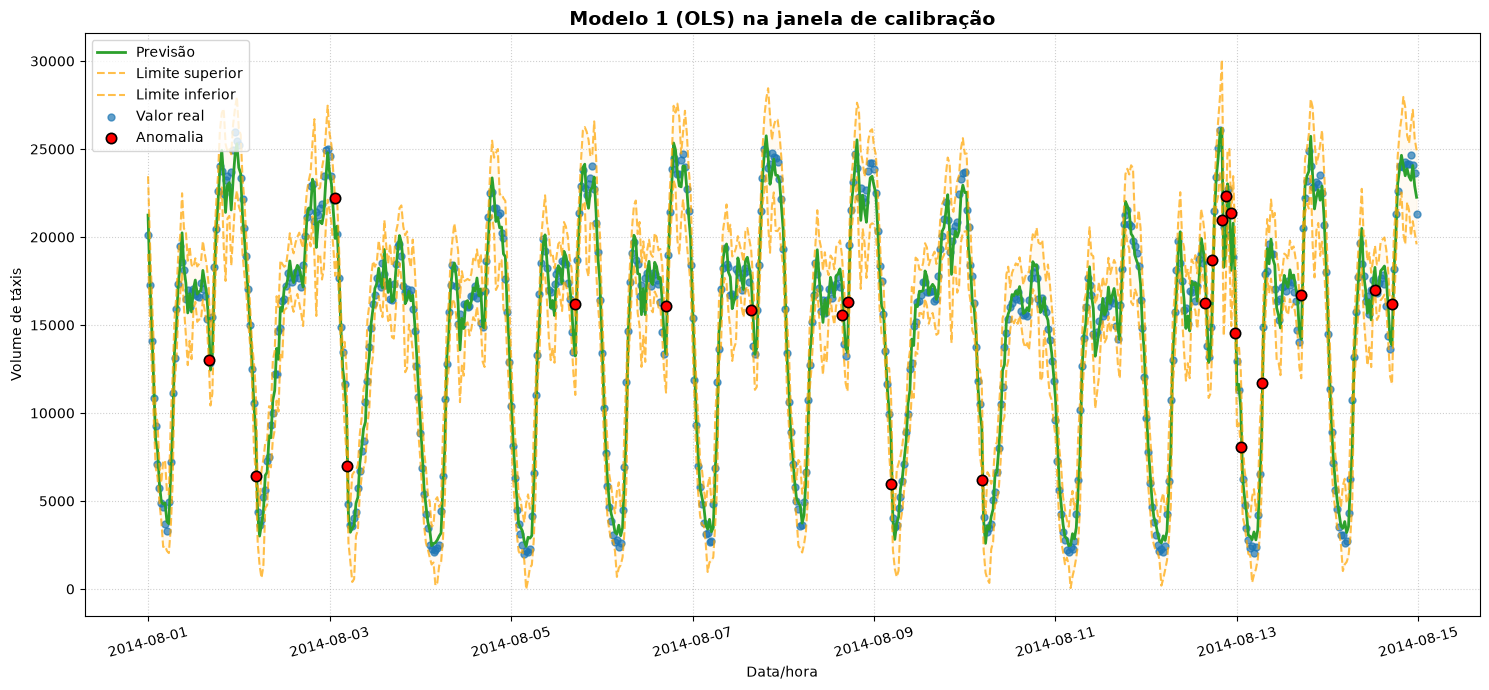

In [9]:
plot_serie_com_bandas(calib1['df'], 'Modelo 1 (OLS) na janela de calibração')

### 03.2 — Suavização da largura da banda por spline (conteúdo da disciplina)

A largura da banda ao longo da calibração é suavizada com uma smoothing
spline (B-spline) para visualizar a tendência da incerteza sem o ruído
ponto a ponto. O parâmetro `s` controla o compromisso entre aderência e
suavidade.

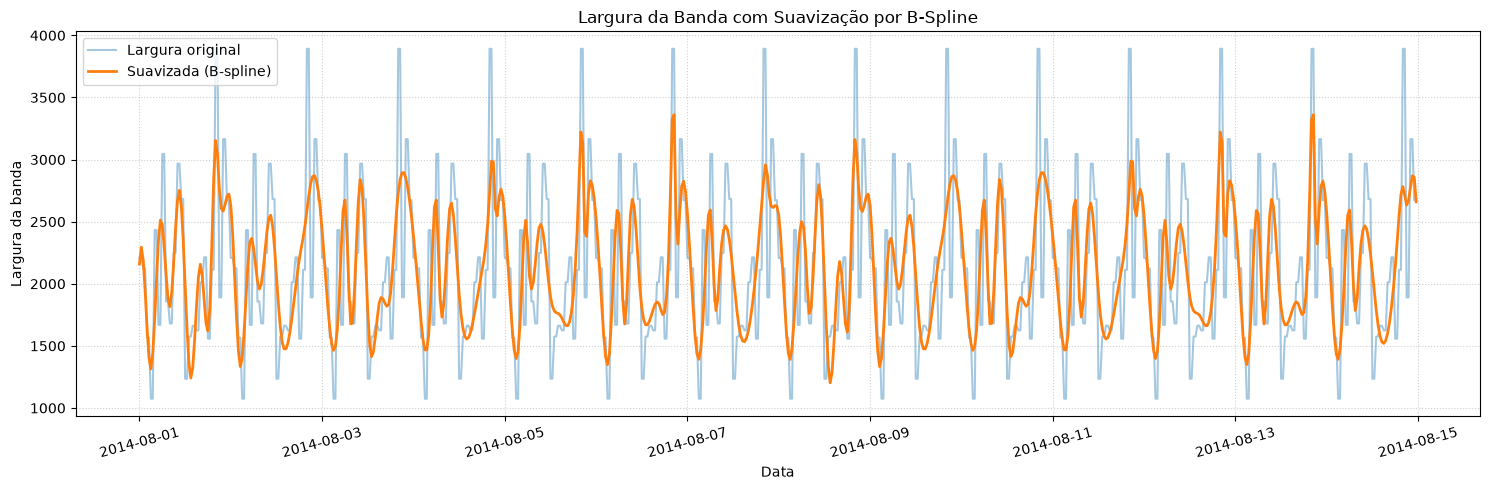

In [10]:
x = np.arange(len(calib1['df']))
y_banda = calib1['df']['banda'].values
spline = UnivariateSpline(x, y_banda, s=len(x) * np.var(y_banda) * 0.5)

import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.plot(calib1['df']['ds'], y_banda, alpha=0.4, label='Largura original')
plt.plot(calib1['df']['ds'], spline(x), linewidth=2, label='Suavizada (B-spline)')
plt.title('Largura da Banda com Suavização por B-Spline')
plt.xlabel('Data')
plt.ylabel('Largura da banda')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 04 — Stream 1: monitoramento até o drift

Quatro sinais monitorados em janelas móveis de 48 observações (24h):
MAE, taxa de anomalias (bilateral), volatilidade dos resíduos e teste KS
(janela de 96, executado a cada 20 observações, com veredito persistente
entre execuções). Drift é declarado com 3+ sinais simultâneos.

In [11]:
monitoramento1, info_drift1 = simular_stream(ols, df_stream1, calib1, FEATURES)

if info_drift1:
    print(f"Drift detectado em {info_drift1['ds']} (posição {info_drift1['posicao']}, "
          f"{info_drift1['sinais']} sinais ativos)")
else:
    print('Stream 1 terminou sem drift — ver contingência no plano de execução.')

Drift detectado em 2014-11-02 01:00:00 (posição 3794, 3 sinais ativos)


> **Comparação v1 → v2**
> - **v1:** cinco sinais monitorados (MAE, taxa de anomalias, volatilidade, KS e largura suavizada da banda por spline); anomalia contabilizada apenas acima da banda superior; veredito do KS zerado entre execuções (o teste roda a cada 20 observações). Drift declarado em 2014-09-14 08:00 (posição 1840; sinais ativos: taxa 0,0625, volatilidade 1493,7, KS p≈0,004; MAE móvel 1221,6, abaixo do threshold 2546,1).
> - **v2:** quatro sinais (o de largura de banda foi removido); anomalia bilateral; veredito do KS persiste até o teste seguinte. Drift declarado em 2014-11-02 01:00 (posição 3794; sinais ativos: taxa de anomalias, volatilidade e KS p≈0,024; MAE móvel 1363,2, abaixo do threshold 2728,4) — data que coincide com a Maratona de NYC, uma das cinco causas documentadas do NAB.
>
> *Comentário:* a largura da banda é uma função fixa do período, definida na calibração; sua média móvel não varia com os dados que chegam, e por isso o quinto sinal não acrescentava informação sobre o stream. A persistência do veredito do KS remove a dependência do alinhamento entre o momento do drift e a cadência do teste. Com a calibração mais longa, os thresholds absorvem a variação sazonal típica e a detecção passa a coincidir com um evento externo documentado.

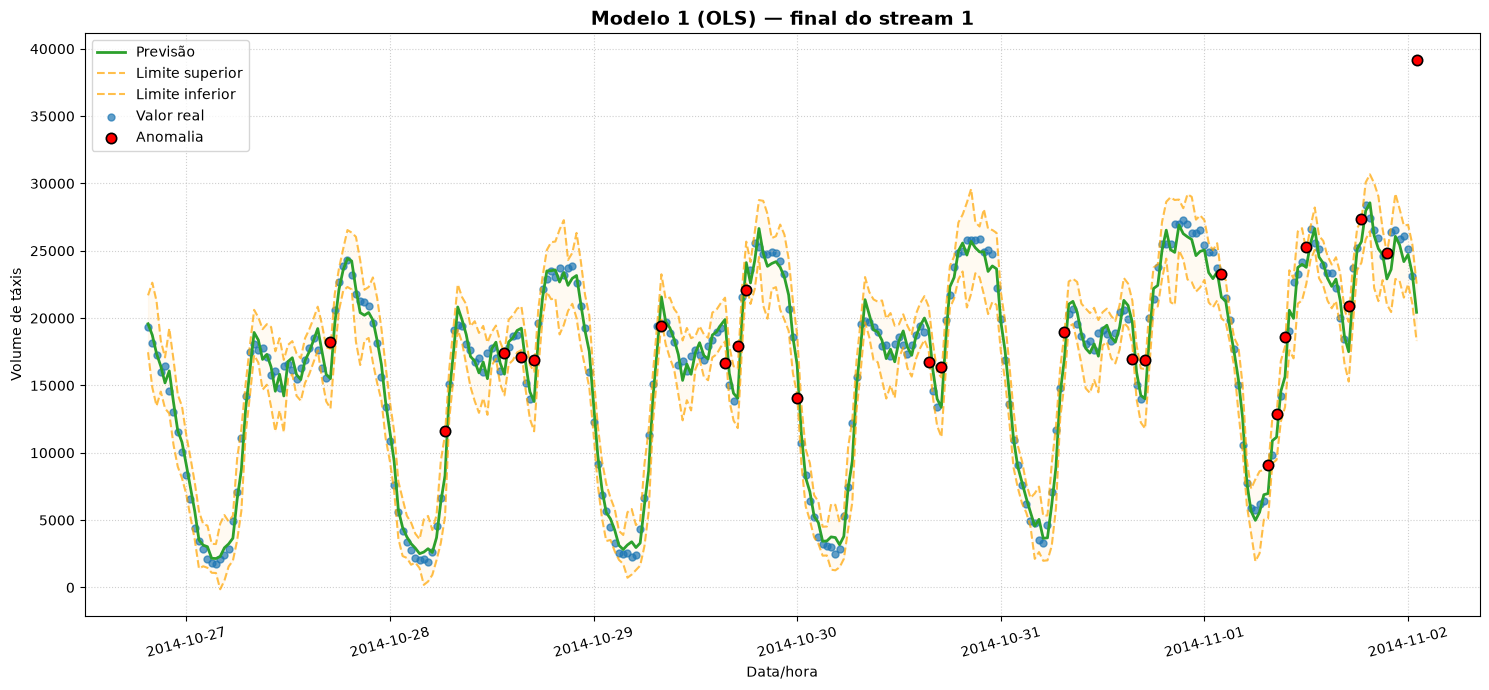

In [12]:
plot_serie_com_bandas(monitoramento1.tail(300), 'Modelo 1 (OLS) — final do stream 1')

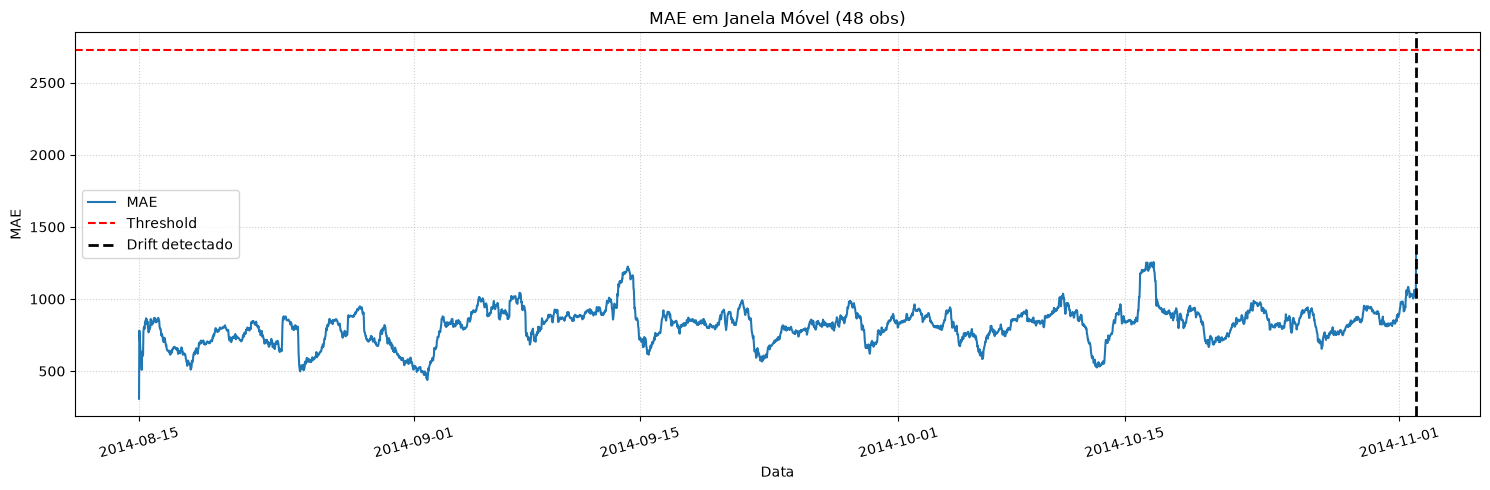

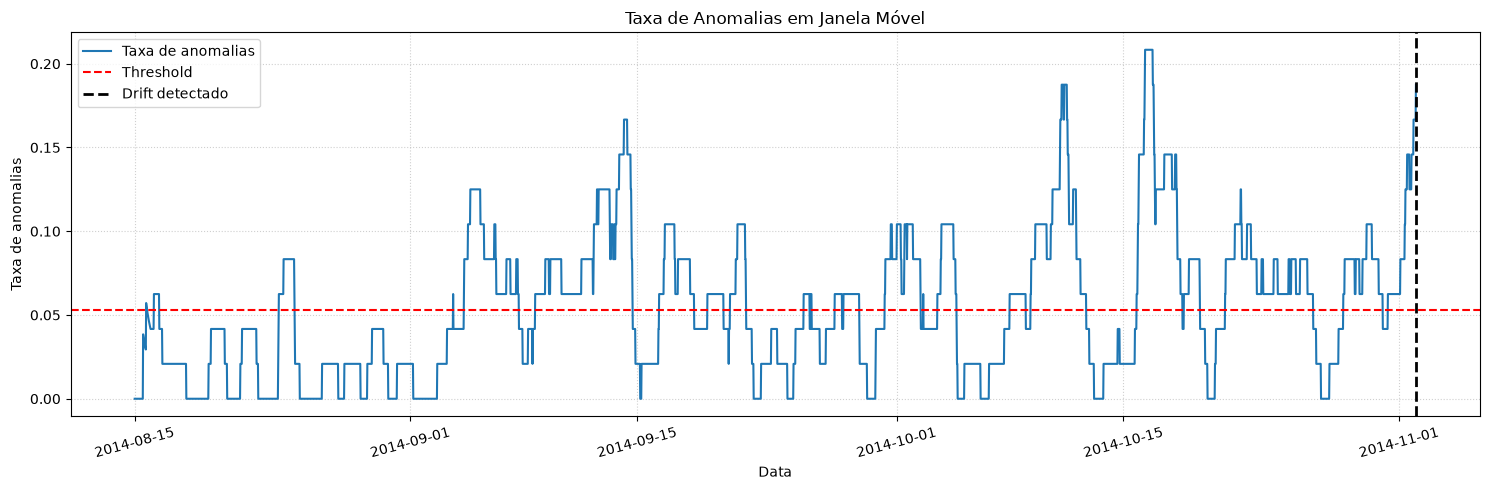

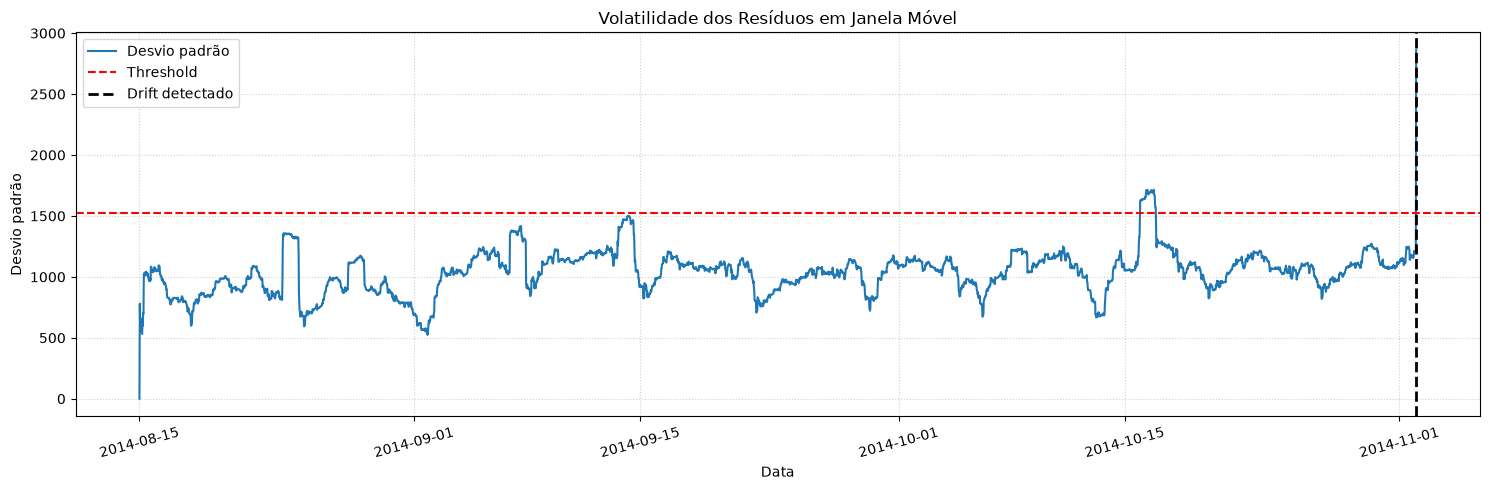

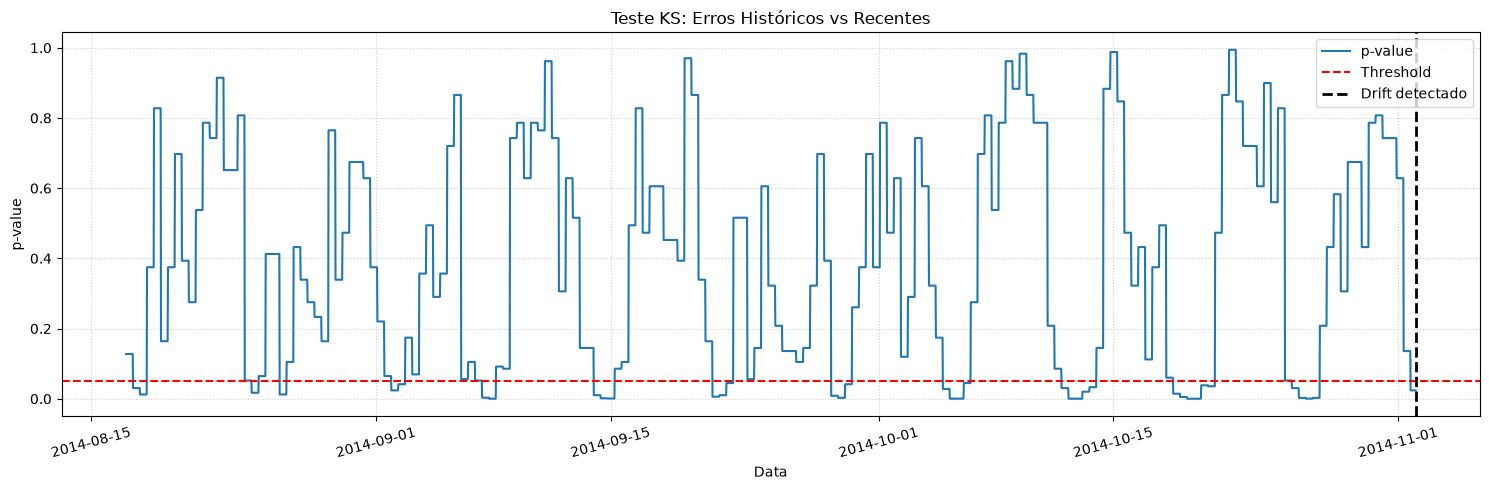

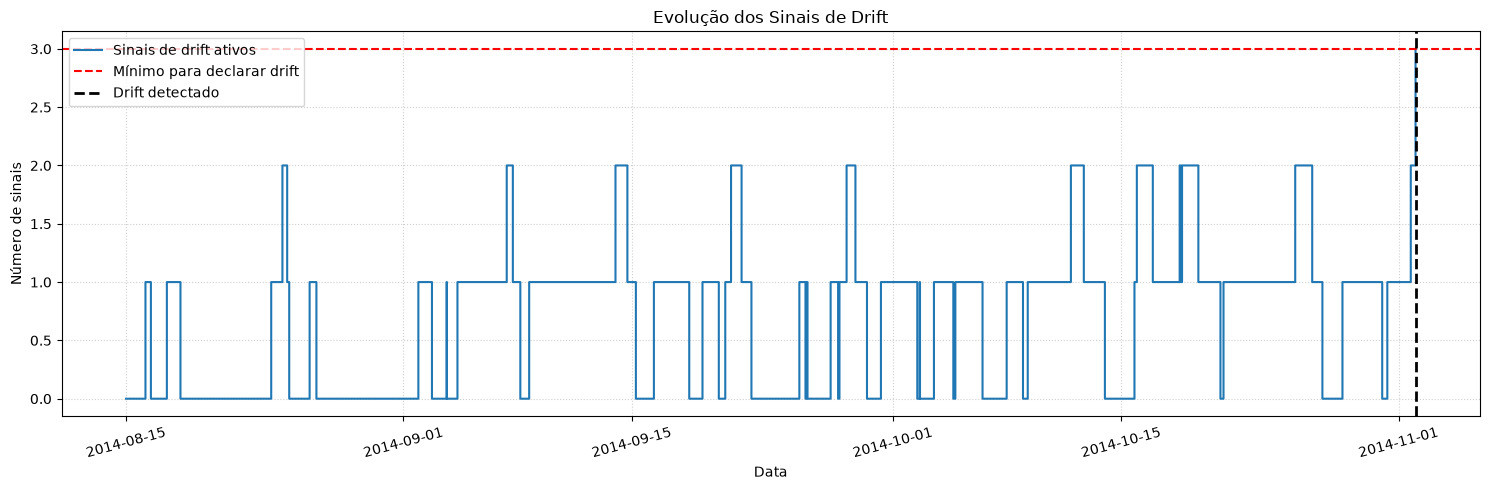

In [13]:
drift_ts1 = info_drift1['ds'] if info_drift1 else None
plot_metrica_movel(monitoramento1, 'mae_movel', 'MAE em Janela Móvel (48 obs)', 'MAE',
                   threshold=calib1['threshold_mae'], drift_ts=drift_ts1)
plot_metrica_movel(monitoramento1, 'taxa_anomalia_movel', 'Taxa de Anomalias em Janela Móvel',
                   'Taxa de anomalias', threshold=calib1['threshold_taxa_anomalia'],
                   drift_ts=drift_ts1)
plot_metrica_movel(monitoramento1, 'std_residuos_movel', 'Volatilidade dos Resíduos em Janela Móvel',
                   'Desvio padrão', threshold=calib1['threshold_residual_std'], drift_ts=drift_ts1)
plot_metrica_movel(monitoramento1.dropna(subset=['ks_p_value']), 'ks_p_value',
                   'Teste KS: Erros Históricos vs Recentes', 'p-value', threshold=0.05,
                   drift_ts=drift_ts1)
plot_sinais_drift(monitoramento1, CONFIG_PADRAO['min_drift_signals'], drift_ts=drift_ts1)

## 05 — Retreino após o drift

Janelas **disjuntas** (ver comparação v1 → v2 abaixo):

- **Retreino:** as últimas `len(df_treino)` observações anteriores ao drift.
- **Calibração 2:** os 14 dias seguintes ao drift.
- **Stream 2:** do fim da calibração 2 até `fim_stream_2`.

Três retreinos na MESMA janela, mais o modelo original como referência:

1. **OLS retreinado** — controle: mede o ganho do retreino em si.
2. **WLS peso-erro** — `w = 1/(1 + |e|/σ)` sobre os erros do OLS antigo
   (robustez a outliers; pontos que o modelo antigo errou pesam menos).
3. **WLS peso-recência** — `w = λ^idade` (adaptação a drift; pontos
   recentes pesam mais).

In [14]:
assert info_drift1 is not None, 'Sem drift no stream 1 — aplicar contingência do plano.'
drift_ts = info_drift1['ds']

df_antes_do_drift = df[df.ds < drift_ts]
df_retreino = df_antes_do_drift.tail(len(df_treino)).copy()

inicio_calib2 = drift_ts
fim_calib2 = inicio_calib2 + pd.Timedelta(days=CONFIG['dias_calibracao_2'])
df_calibracao2 = df[(df.ds >= inicio_calib2) & (df.ds < fim_calib2)].copy()
df_stream2 = df[(df.ds >= fim_calib2) & (df.ds < CONFIG['fim_stream_2'])].copy()

assert df_retreino['ds'].max() < df_calibracao2['ds'].min()
assert df_calibracao2['ds'].max() < df_stream2['ds'].min()
print(f'retreino: {len(df_retreino)} | calibração 2: {len(df_calibracao2)} | stream 2: {len(df_stream2)}')

retreino: 1464 | calibração 2: 672 | stream 2: 2878


> **Comparação v1 → v2**
> - **v1:** janela de retreino = 1483 observações anteriores ao drift; calibração do modelo 2 = `df_stream[1483:]` (389 obs). Das 389 observações de calibração, 357 (91,8%) também pertenciam à janela de retreino.
> - **v2:** retreino = 1464 observações anteriores ao drift; calibração 2 = 14 dias seguintes ao drift (672 obs); stream 2 na sequência (2878 obs). A disjunção entre as três janelas é verificada por `assert`.
>
> *Comentário:* quando a calibração compartilha observações com o treino, os erros medidos refletem dados que o modelo já ajustou, e os thresholds derivados descrevem um cenário mais favorável que o de operação. Janelas disjuntas mantêm a calibração como estimativa de comportamento em dados não vistos.

In [15]:
erro_ols_antigo = df_retreino['y'] - ols.predict(df_retreino[FEATURES])

peso_erro = 1 / (1 + erro_ols_antigo.abs() / erro_ols_antigo.std())
peso_erro = peso_erro.clip(lower=CONFIG['peso_minimo'], upper=1.0)

idade = np.arange(len(df_retreino))[::-1]  # 0 = observação mais recente
peso_recencia = CONFIG['lambda_recencia'] ** idade

ols_retreinado = OrdinaryLeastSquares().fit(df_retreino[FEATURES], df_retreino[TARGET])
wls_erro = WeightedLeastSquares(ridge_eps=1e-8).fit(
    df_retreino[FEATURES], df_retreino[TARGET], sample_weight=peso_erro)
wls_recencia = WeightedLeastSquares(ridge_eps=1e-8).fit(
    df_retreino[FEATURES], df_retreino[TARGET], sample_weight=peso_recencia)

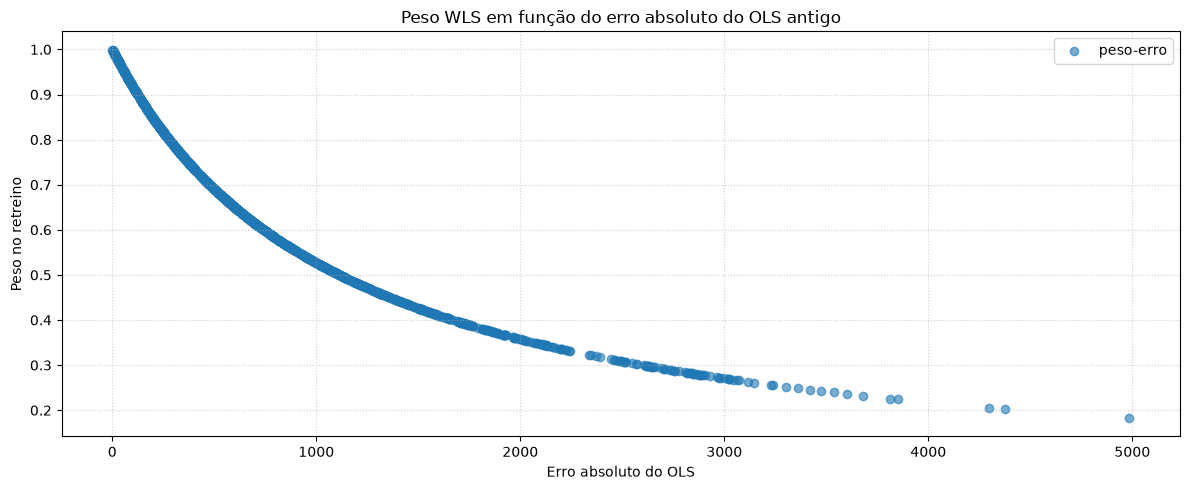

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.scatter(erro_ols_antigo.abs(), peso_erro, alpha=0.6, label='peso-erro')
plt.title('Peso WLS em função do erro absoluto do OLS antigo')
plt.xlabel('Erro absoluto do OLS')
plt.ylabel('Peso no retreino')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 06 — Comparação justa dos modelos

Primeiro, erro de previsão na calibração 2 (mesma janela para todos).
Depois, cada modelo é calibrado nessa janela e submetido ao stream 2;
comparamos quantas observações cada um sobrevive até declarar drift.

In [17]:
def avaliar(modelo, df_avaliacao):
    yhat = modelo.predict(df_avaliacao[FEATURES])
    erro = df_avaliacao['y'] - yhat
    return {'MAE': erro.abs().mean(), 'RMSE': np.sqrt((erro ** 2).mean())}

modelos = {
    'OLS original (sem retreino)': ols,
    'OLS retreinado': ols_retreinado,
    'WLS peso-erro': wls_erro,
    'WLS peso-recência': wls_recencia,
}

tabela_erro = pd.DataFrame({nome: avaliar(m, df_calibracao2) for nome, m in modelos.items()}).T
tabela_erro

,MAE,RMSE
OLS original (sem retreino),940.437038,1654.839143
OLS retreinado,928.365436,1735.800716
WLS peso-erro,914.566087,1705.997983
WLS peso-recência,928.256636,1735.887905


In [18]:
resultados = {}
for nome, modelo in modelos.items():
    calib_m = calibrar(modelo, df_calibracao2, FEATURES)
    monit_m, info_m = simular_stream(modelo, df_stream2, calib_m, FEATURES)
    resultados[nome] = {'monitoramento': monit_m, 'drift': info_m}

tabela_drift = pd.DataFrame({
    nome: {
        'houve drift': r['drift'] is not None,
        'observações até o drift': (r['drift']['posicao'] + 1) if r['drift'] else len(r['monitoramento']),
        'data do drift': r['drift']['ds'] if r['drift'] else '—',
    }
    for nome, r in resultados.items()
}).T
tabela_drift

,houve drift,observações até o drift,data do drift
OLS original (sem retreino),False,2878,—
OLS retreinado,False,2878,—
WLS peso-erro,False,2878,—
WLS peso-recência,False,2878,—


> **Comparação v1 → v2**
> - **v1:** comparação entre dois modelos — o OLS treinado na janela inicial e um WLS retreinado com dados recentes (pesos inversos ao erro absoluto do OLS anterior). Após o retreino, o stream de 15/09/2014 a 15/01/2015 terminou sem novo drift.
> - **v2:** quatro modelos avaliados nas mesmas janelas — OLS original, OLS retreinado (controle), WLS peso-erro e WLS peso-recência. Nenhum declarou drift no stream 2; no desempate pelo MAE da calibração 2: WLS peso-erro (914,57), WLS peso-recência (928,26), OLS retreinado (928,37), OLS original (940,44).
>
> *Comentário:* sem um OLS retreinado na mesma janela, não é possível separar o efeito do retreino do efeito da ponderação; a v2 acrescenta esse controle. Nos dados avaliados, a ponderação por erro apresentou o menor MAE, inclusive em relação ao controle.

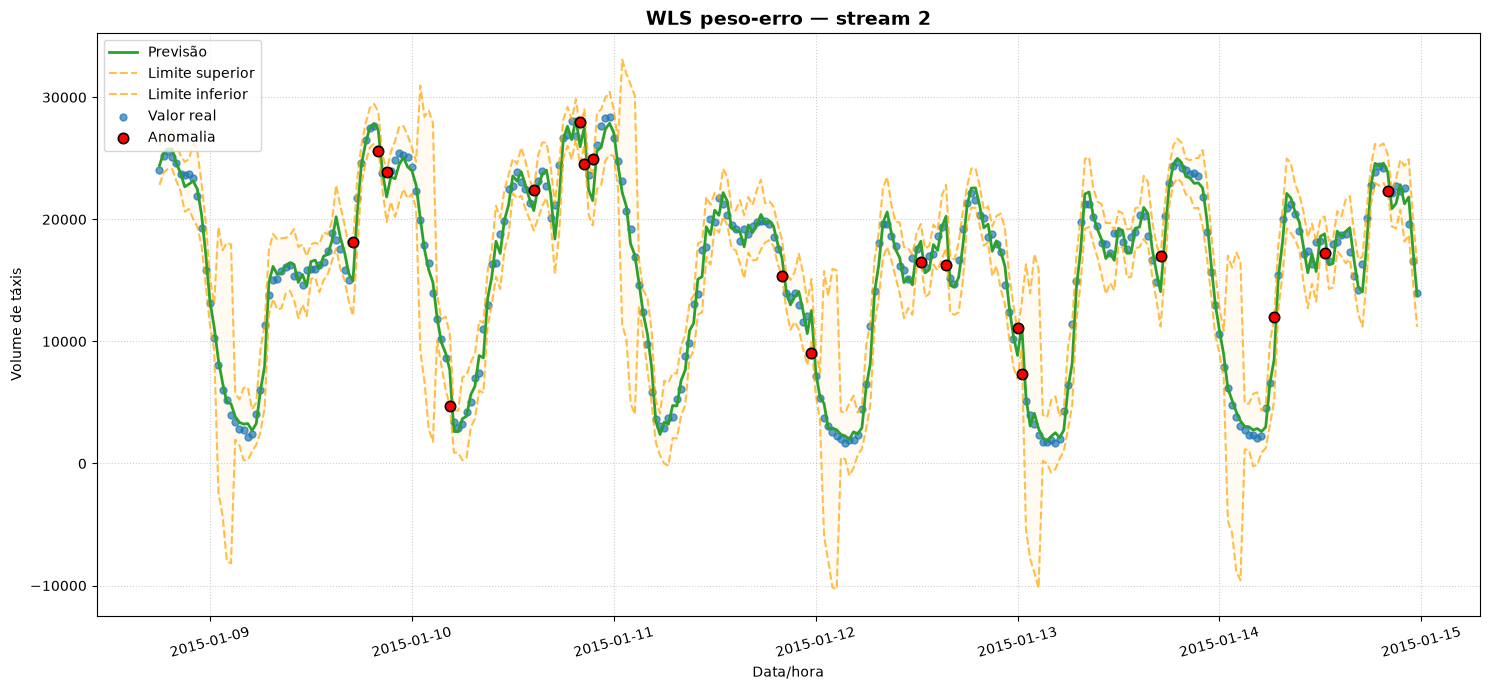

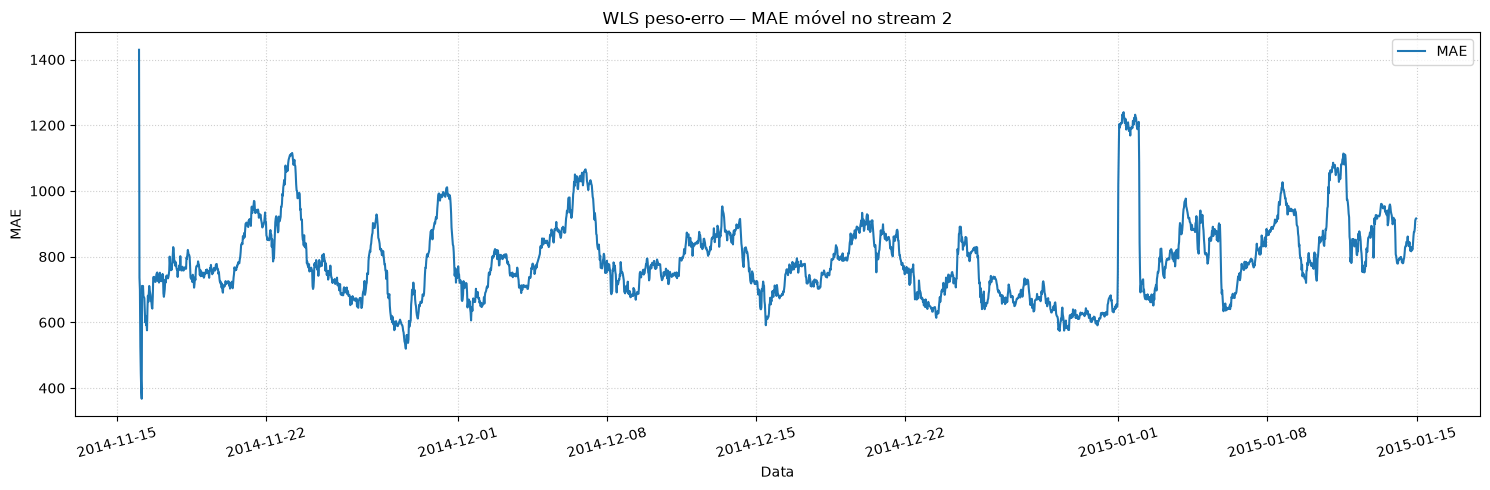

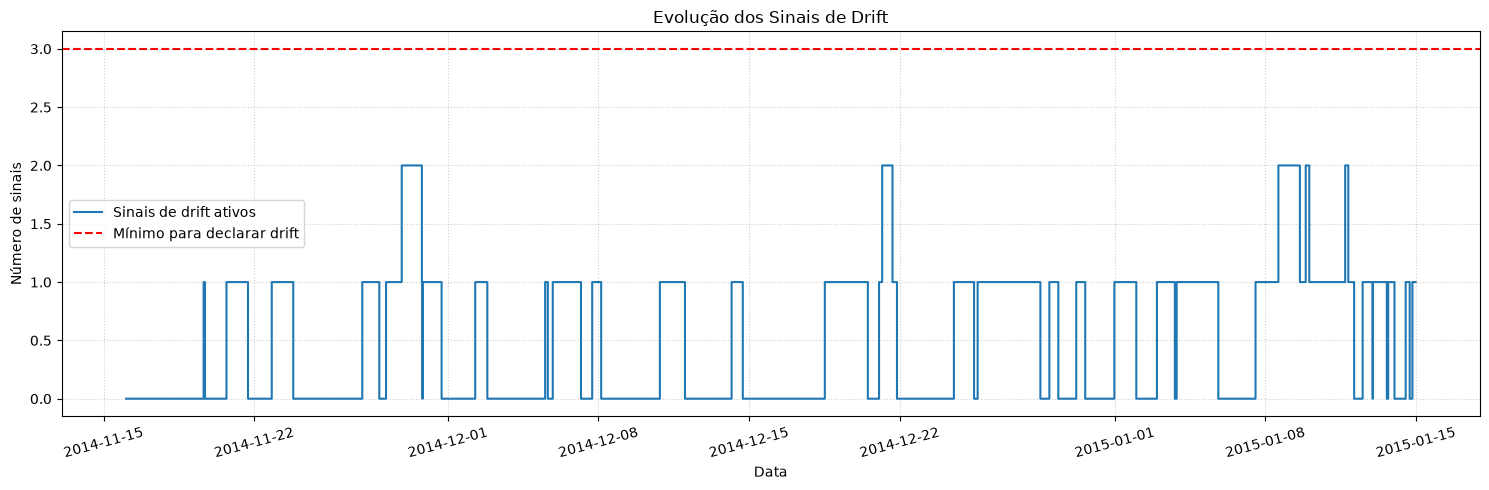

In [19]:
melhor = 'WLS peso-erro'  # ajustar para o vencedor real da tabela acima
monit_melhor = resultados[melhor]['monitoramento']
info_melhor = resultados[melhor]['drift']
drift_ts2 = info_melhor['ds'] if info_melhor else None

plot_serie_com_bandas(monit_melhor.tail(300), f'{melhor} — stream 2')
plot_metrica_movel(monit_melhor, 'mae_movel', f'{melhor} — MAE móvel no stream 2', 'MAE',
                   drift_ts=drift_ts2)
plot_sinais_drift(monit_melhor, CONFIG_PADRAO['min_drift_signals'], drift_ts=drift_ts2)

## 07 — Resumo das diferenças v1 → v2

| Aspecto | v1 | v2 | Motivo |
|---|---|---|---|
| Média móvel | `rolling_mean_5` (média dos lags 1–5) | `rolling_mean_24` | posto completo da matriz de projeto |
| Posto / cond(XᵀX) | 10 de 11 / ~10¹⁶ | 11 de 11 / ~10¹¹ | estabilidade das equações normais |
| Calibração | 6 dias (288 obs) | 14 dias (672 obs) | amostra suficiente por grupo |
| Banda | z·σ(dia, hora) com piso q99 | z·σ(hora), sem piso | σ por grupo estável; taxa de calibração não nula |
| Taxa de anomalias na calibração | 0,0000 | 0,0327 | threshold derivado dos dados |
| Anomalia no stream | apenas acima da banda | bilateral | consistência com a calibração |
| Sinais de drift | 5 (inclui largura da banda) | 4 | banda fixa por período não reage ao stream |
| Veredito do KS | zerado entre execuções | persiste até o teste seguinte | independência da cadência |
| Drift do OLS | 2014-09-14 (posição 1840) | 2014-11-02, Maratona de NYC (posição 3794) | consequência dos thresholds recalibrados |
| Janelas do retreino | 91,8% da calibração 2 dentro do retreino | disjuntas, verificadas por `assert` | calibração sobre dados não vistos |
| Modelos comparados | OLS inicial vs WLS retreinado | 4 modelos nas mesmas janelas, com controle | separar efeito do retreino e do peso |
| Código | células autocontidas (143 células) | módulos `src/` reutilizáveis | reuso e organização |
| Diagnóstico numérico | ausente | cond(XᵀX), padronização e SVD (seções 02–02.2) | verificação de posto e efeito de escala |

## 08 — Conclusão

O modelo 1 (OLS original, treinado até 01/08/2014) monitorou o stream 1
por quase 2,5 meses sem sinais de degradação — desde a calibração em
15/08/2014 até declarar drift em **2014-11-02 01:00** (posição 3794),
coincidindo com a **Maratona de Nova York**, com 3 dos 4 sinais ativos
simultaneamente (taxa de anomalias, volatilidade dos resíduos e teste KS,
com p = 0.024; o MAE móvel, 1363.17, permaneceu abaixo do threshold de
2728.40). Vale registrar que o teste KS — cuja confiabilidade é limitada
pela autocorrelação dos resíduos, como discutido nas limitações abaixo —
foi um dos três sinais que sustentaram a declaração de drift.

O retreino foi feito em janelas **disjuntas** (retreino: 1464 obs |
calibração 2: 672 obs | stream 2: 2878 obs, cobrindo Thanksgiving, Natal
e Ano Novo). Nesse stream 2, **nenhum dos quatro modelos** (OLS original
sem retreino, OLS retreinado, WLS peso-erro, WLS peso-recência) declarou
drift — todos sobreviveram às 2878 observações completas. O critério
primário de comparação deste projeto (robustez medida por sobrevivência
no stream) portanto não diferenciou os modelos nesta rodada: os quatro
absorveram igualmente bem a sazonalidade dos feriados de fim de ano
dentro dessa janela de retreino.

O desempate coube ao erro de previsão na calibração 2 (MAE/RMSE, mesma
janela de 672 observações para todos):

| Modelo | MAE | RMSE |
|---|---|---|
| OLS original (sem retreino) | 940.44 | 1654.84 |
| OLS retreinado (controle) | 928.37 | 1735.80 |
| **WLS peso-erro (vencedor)** | **914.57** | **1706.00** |
| WLS peso-recência | 928.26 | 1735.89 |

**WLS peso-erro** venceu com a menor MAE do grupo e RMSE inferior à do
controle OLS retreinado (1706,00 < 1735,80); a menor RMSE absoluta ficou
com o OLS original sem retreino (1654,84) — coerente com o peso-erro
rebaixar outliers no ajuste, otimizando o erro típico (MAE) mais do que
a cauda da distribuição (RMSE). Ainda assim, a vitória de MAE e a RMSE
à frente do controle são evidência de que parte do ganho vem do próprio
esquema de ponderação (robustez a outliers via `w = 1/(1 + |erro|/σ)`),
não apenas do fato de ter sido retreinado.
WLS peso-recência, por outro lado, ficou praticamente colado ao
controle (diferença de MAE inferior a 0,2 ponto, ~0,01%), sugerindo que
`lambda_recencia = 0.999` não trouxe adaptação perceptível dentro dessa
janela de 1464 observações.

**Ressalvas sobre a leitura desses números:**

1. **O empate de sobrevivência é o resultado mais honesto desta rodada.**
   Como nenhum modelo detectou drift no stream 2, a comparação não testa
   robustez a um drift real — testa apenas qualidade de ajuste na
   calibração. Não é correto afirmar que o WLS "sobrevive mais" a um
   drift de fim de ano; apenas que ajusta melhor os dados vistos até
   aqui.
2. **A calibração 2 começa exatamente na anomalia da Maratona**, então
   seus thresholds (MAE, taxa de anomalia, volatilidade) foram
   calibrados sobre uma janela relativamente mais ruidosa e ficaram, por
   construção, mais largos do que os da calibração 1. Isso facilita a
   sobrevivência de qualquer um dos quatro modelos no stream 2 e é parte
   da explicação para o empate acima — uma ressalva a manter em mente ao
   ler a tabela de sobrevivência.
3. **Mesmo com essa ressalva, a diferença de MAE/RMSE entre WLS peso-erro
   e o controle OLS retreinado é real e ocorre na mesma janela de
   dados** — ambos foram calibrados nos mesmos 672 pontos da calibração
   2. Isso é evidência de que o peso, e não apenas o retreino, contribui
   para o ganho observado.

**Limitações conhecidas:**

- O teste KS é reexecutado a cada 20 observações sobre resíduos
  autocorrelacionados — viola a hipótese de independência do teste e
  infla a taxa de falsos positivos.
- As bandas de calibração ficam congeladas: não se adaptam à medida que
  o stream avança, mesmo quando a distribuição muda gradualmente sem
  cruzar o limiar de drift.

**Trabalhos futuros:**

- IRLS (reponderação iterativa) no retreino, em vez de um único passo de
  WLS.
- Bandas adaptativas, recalculadas com resíduos recentes do próprio
  stream.
- Resolução das equações normais via fatoração QR/Cholesky, com análise
  de estabilidade numérica.